# Cas de tests - PMC

In [85]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'python')))

from pmc import init, init_regression, entrainer, predire

In [86]:
COULEURS = ['blue', 'red', 'green']

def precision(predict_fn, X, Y):
    return 100 * sum(predict_fn(x) == y for x, y in zip(X, Y)) / len(X)

def frontiere(predict_fn, X, Y, titre):
    X = np.array(X, dtype=float)
    n = max(Y) + 1
    cmap = ListedColormap(COULEURS[:n])

    pas = 0.05
    vx = np.arange(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, pas)
    vy = np.arange(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, pas)
    Z = [[predict_fn([x, y]) for x in vx] for y in vy]
    plt.contourf(vx, vy, Z, levels=np.arange(-0.5, n), cmap=cmap, alpha=0.15)

    for classe in range(n):
        pts = X[[y == classe for y in Y]]
        plt.scatter(pts[:, 0], pts[:, 1], color=COULEURS[classe])
    plt.title(titre)
    plt.show()

def courbe(predict_fn, X, Y, titre):
    X_np = np.array(X, dtype=float)
    xs = np.linspace(X_np.min() - 0.5, X_np.max() + 0.5, 100)
    plt.scatter(X_np, Y)
    plt.plot(xs, [predict_fn([x]) for x in xs], color='orange')
    plt.title(titre)
    plt.show()

def points3d(predict_fn, X, Y, titre):
    X_np = np.array(X, dtype=float)
    Y_pred = [predict_fn(x) for x in X]
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    # Surface de prediction
    GX, GY = np.meshgrid(np.linspace(X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5, 30),
                         np.linspace(X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5, 30))
    GZ = np.array([[predict_fn([x, y]) for x, y in zip(lx, ly)] for lx, ly in zip(GX, GY)])
    ax.plot_surface(GX, GY, GZ, color='orange', alpha=0.3)

    ax.scatter(X_np[:, 0], X_np[:, 1], Y, color='blue', label='reel')
    ax.scatter(X_np[:, 0], X_np[:, 1], Y_pred, color='orange', label='predit')
    plt.title(titre)
    plt.legend()
    plt.show()

In [87]:
def test_binaire(X, Y_signe, nb, cachees, epochs_mlp, alpha_mlp):
    Y_lab = [0 if y == 1 else 1 for y in Y_signe]  # 0 = classe "1" (bleu), 1 = classe "-1" (rouge)

    init(2, cachees, 1)
    entrainer(X, [[y] for y in Y_signe], epochs=epochs_mlp, alpha=alpha_mlp)
    predict_mlp = lambda p: 0 if predire(p, 1)[0] >= 0 else 1
    frontiere(predict_mlp, X, Y_lab, f"MLP - Cas {nb} ({precision(predict_mlp, X, Y_lab):.0f}%)")


def test_multiclasse(X, Y, nb, nb_classes, cachees, epochs_mlp, alpha_mlp):
    Y_lab = [int(np.argmax(y)) for y in Y]

    init(2, cachees, nb_classes)
    entrainer(X, Y, epochs=epochs_mlp, alpha=alpha_mlp)
    predict_mlp = lambda p: int(np.argmax(predire(p, nb_classes)))
    frontiere(predict_mlp, X, Y_lab, f"MLP - Cas {nb} ({precision(predict_mlp, X, Y_lab):.0f}%)")


def test_regression(X, Y, nb, cachees, epochs_mlp, alpha_mlp, plot):
    init_regression(len(X[0]), cachees, 1)
    entrainer(X, [[y] for y in Y], epochs=epochs_mlp, alpha=alpha_mlp)
    predict_mlp = lambda p: predire(p, 1)[0]
    plot(predict_mlp, X, Y, f"MLP - Cas {nb}")

## Classification

### Cas 1 : Linear Simple -- attendu Linear OK, MLP OK

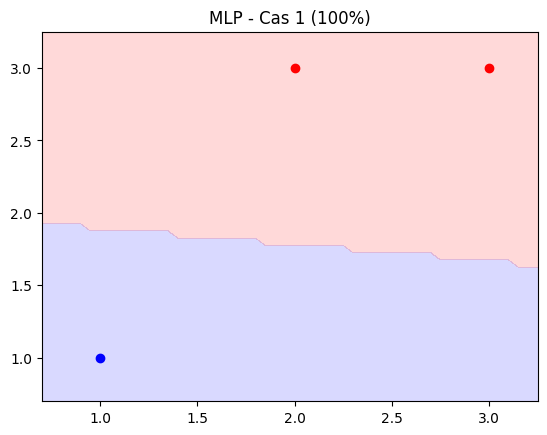

In [88]:
X = [[1, 1], [2, 3], [3, 3]]
Y = [1, -1, -1]
test_binaire(X, Y, nb=1, cachees=2, epochs_mlp=3000, alpha_mlp=0.1)

### Cas 2 : Linear Multiple -- attendu Linear OK, MLP OK

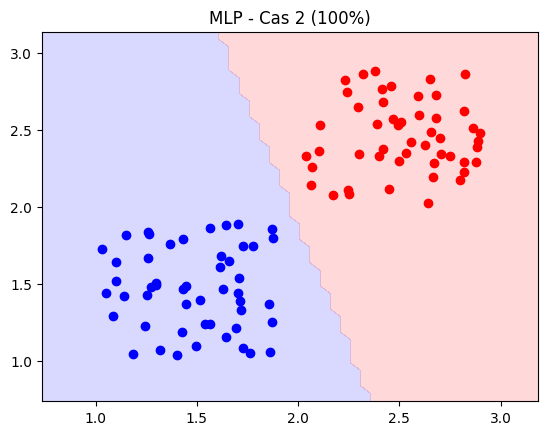

In [89]:
X = np.concatenate([
    np.random.random((50, 2)) * 0.9 + np.array([1, 1]),
    np.random.random((50, 2)) * 0.9 + np.array([2, 2]),
]).tolist()
Y = (np.concatenate([np.ones((50,)), np.ones((50,)) * -1.0])).tolist()
test_binaire(X, Y, nb=2, cachees=2, epochs_mlp=3000, alpha_mlp=0.1)

### Cas 3 : XOR -- attendu Linear KO, MLP OK

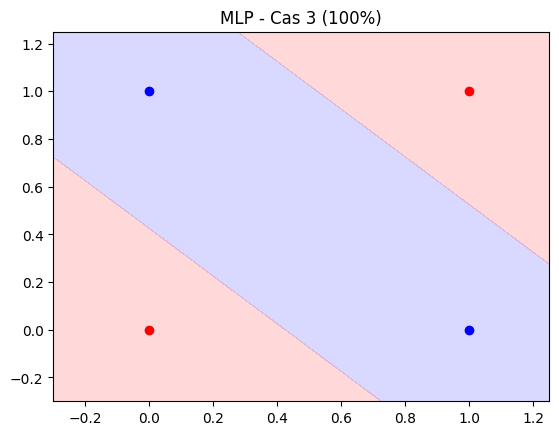

In [90]:
X = [[1, 0], [0, 1], [0, 0], [1, 1]]
Y = [1, 1, -1, -1]
test_binaire(X, Y, nb=3, cachees=2, epochs_mlp=10000, alpha_mlp=0.1)

### Cas 4 : Cross -- attendu Linear KO, MLP OK

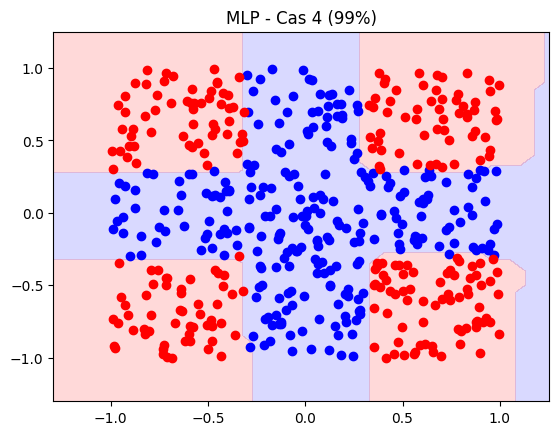

In [91]:
X = (np.random.random((500, 2)) * 2.0 - 1.0).tolist()
Y = [1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X]
test_binaire(X, Y, nb=4, cachees=8, epochs_mlp=5000, alpha_mlp=0.05)

### Cas 5 : Multi Linear 3 classes - attendu Linear OK, MLP OK

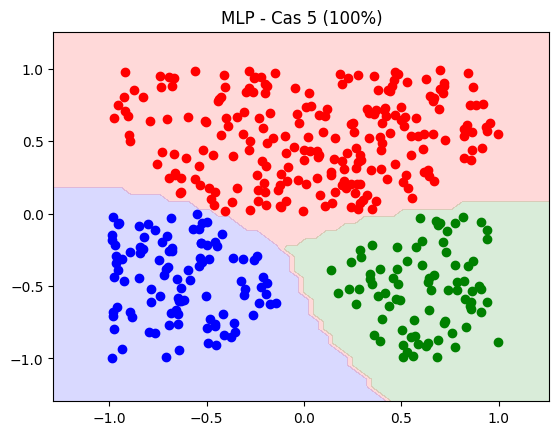

In [92]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([
    [1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
    [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
    [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
    [-1, -1, -1]
    for p in X
])
garde = [not np.all(arr == [-1, -1, -1]) for arr in Y]
X, Y = X[garde].tolist(), Y[garde].tolist()
test_multiclasse(X, Y, nb=5, nb_classes=3, cachees=4, epochs_mlp=5000, alpha_mlp=0.05)

### Cas 6 : Multi Cross -- attendu Linear KO, MLP OK


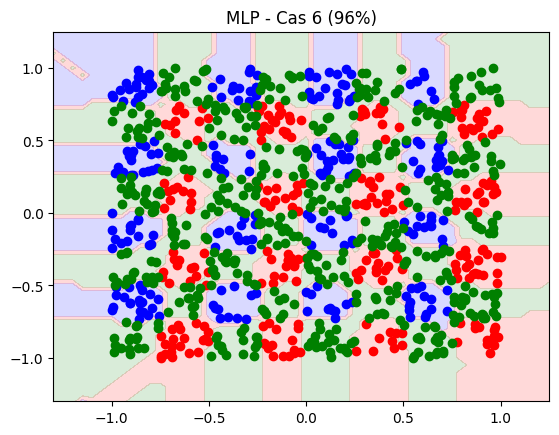

In [93]:
X = (np.random.random((1000, 2)) * 2.0 - 1.0).tolist()
Y = [
    [1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else
    [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else
    [-1, -1, 1]
    for p in X
]
test_multiclasse(X, Y, nb=6, nb_classes=3, cachees=24, epochs_mlp=15000, alpha_mlp=0.005)

## Regression

### Cas 1 : Linear Simple 2D -- attendu Linear OK, MLP OK

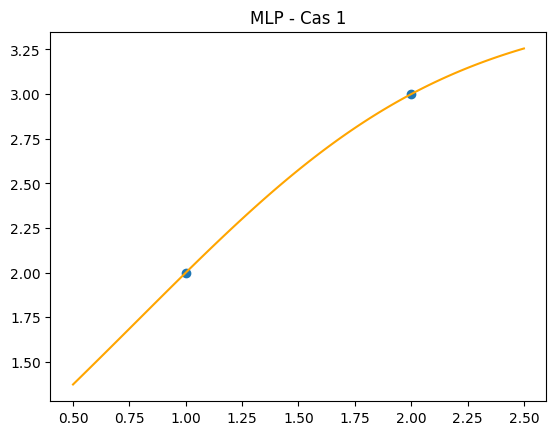

In [94]:
X = [[1], [2]]
Y = [2, 3]
test_regression(X, Y, nb=1, cachees=2, epochs_mlp=3000, alpha_mlp=0.1, plot=courbe)

### Cas 2 : Non Linear Simple 2D -- attendu Linear OK, MLP OK

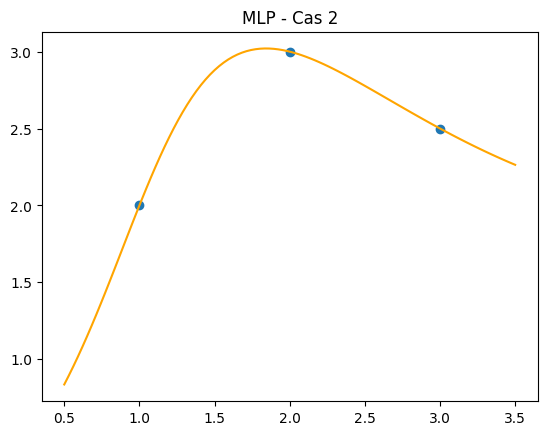

In [95]:
X = [[1], [2], [3]]
Y = [2, 3, 2.5]
test_regression(X, Y, nb=2, cachees=4, epochs_mlp=5000, alpha_mlp=0.05, plot=courbe)

### Cas 3 : Linear Simple 3D -- attendu Linear OK, MLP OK

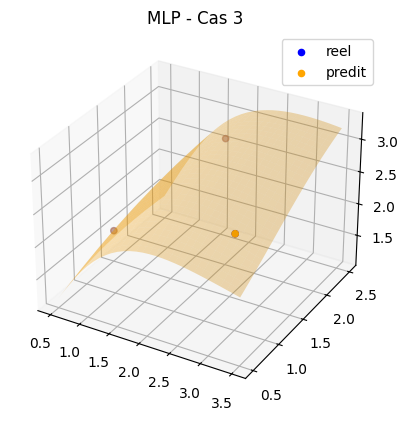

In [96]:
X = [[1, 1], [2, 2], [3, 1]]
Y = [2, 3, 2.5]
test_regression(X, Y, nb=3, cachees=2, epochs_mlp=3000, alpha_mlp=0.05, plot=points3d)

### Cas 4 : Linear Tricky 3D -- attendu Linear OK, MLP OK

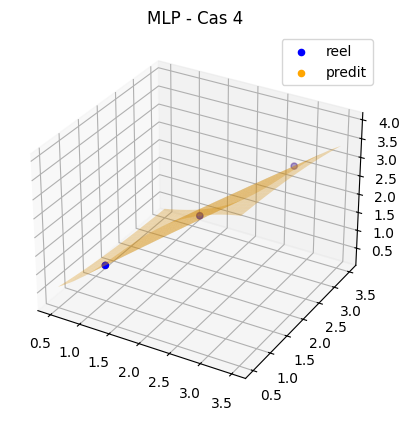

In [97]:
X = [[1, 1], [2, 2], [3, 3]]
Y = [1, 2, 3]
test_regression(X, Y, nb=4, cachees=2, epochs_mlp=3000, alpha_mlp=0.05, plot=points3d)

### Cas 5 : Non Linear Simple 3D -- attendu Linear KO, MLP OK


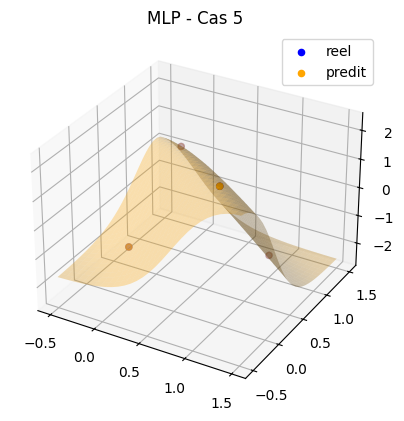

In [98]:
X = [[1, 0], [0, 1], [1, 1], [0, 0]]
Y = [2, 1, -2, -1]
test_regression(X, Y, nb=5, cachees=2, epochs_mlp=8000, alpha_mlp=0.1, plot=points3d)